In [109]:
from scipy.ndimage import label

def mask_to_yolo_boxes_multi(single_mask, class_id, img_w, img_h, connectivity=1, lth = 5 ,th = 300):
    """
    single_mask: (H, W) binary/boolean mask (may contain multiple objects).
    Returns list of [class_id, x_c_n, y_c_n, w_n, h_n].
    """
    labeled, num = label(single_mask, structure=None if connectivity == 1 else np.ones((3, 3)))
    boxes = []

    for comp_id in range(1, num + 1):
        ys, xs = np.where(labeled == comp_id)
        if len(xs) == 0:
            continue

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()

        box_w  = x_max - x_min + 1
        box_h  = y_max - y_min + 1
        
        if (box_w < th and box_h < th) and (box_w > lth and box_h > lth) :
        
            x_c    = x_min + box_w / 2.0
            y_c    = y_min + box_h / 2.0

            x_c_n = x_c / img_w
            y_c_n = y_c / img_h
            w_n   = box_w / img_w
            h_n   = box_h / img_h

            boxes.append([class_id, x_c_n, y_c_n, w_n, h_n])

    return boxes

In [110]:
import os
import glob
import csv
import numpy as np

from scipy.ndimage import label  # ensure imported
# mask_to_yolo_boxes_multi assumed defined above

DATA_DIR = "/home/arch/LCPB/2026/code/Computational-Physics-2026/data/MR/data/processed/tiles/marius_hills"       # folder containing *.npz
OUT_CSV  = "all_boxes.csv"

npz_paths = glob.glob(os.path.join(DATA_DIR, "*.npz"))

all_rows = []  # each row: [npz_path, class_id, x_center, y_center, width, height]

for npz_path in npz_paths:
    data = np.load(npz_path)
    img   = data["image"]   # (3, H, W)
    masks = data["mask"]    # (7, H, W)

    _, H, W = img.shape

    for class_id in range(0,7):  # 0..6
        m = masks[class_id] > 0  # boolean
        
        if class_id==0:
            boxes = mask_to_yolo_boxes_multi(m, class_id, W, H,th=100)
        else:
            
            boxes = mask_to_yolo_boxes_multi(m, class_id, W, H,th=300)

        for (cls, x_c, y_c, w, h) in boxes:
            all_rows.append([npz_path, cls, x_c, y_c, w, h])

# Write single global CSV
with open(OUT_CSV, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["npz_path", "class_id", "x_center", "y_center", "width", "height"])
    writer.writerows(all_rows)

print(f"Saved {len(all_rows)} boxes from {len(npz_paths)} npz files to {OUT_CSV}")

Saved 142706 boxes from 15935 npz files to all_boxes.csv


/tmp/ipykernel_70218/937273608.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


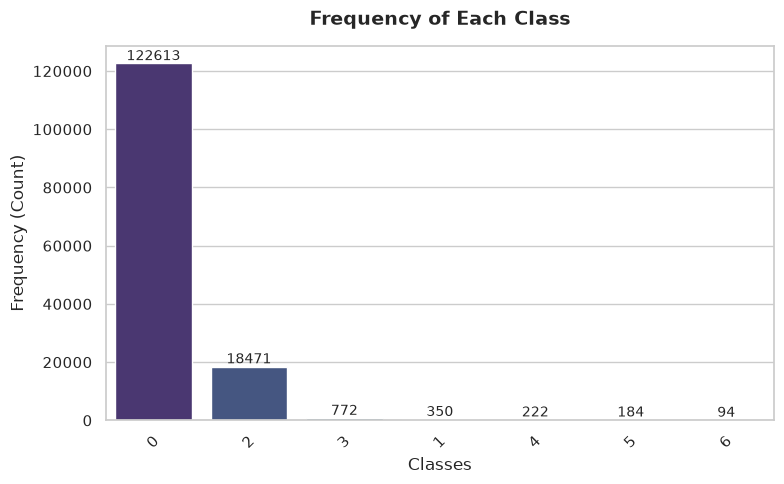

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ۱. خواندن فایل CSV
# نام فایل خودت را جایگزین 'your_file.csv' کن
df = pd.read_csv("./all_boxes.csv")

# تنظیم استایل نمودار برای قشنگ‌تر شدن
sns.set_theme(style="whitegrid")

# ۲. رسم نمودار فراوانی (Count Plot)
plt.figure(figsize=(8, 5))
# نام ستون کلاس‌ها را به جای 'class_column' بنویس
ax = sns.countplot(
    data=df, x="class_id", palette="viridis", order=df["class_id"].value_counts().index
)

# ۳. شخصی‌سازی و زیباسازی نمودار
plt.title("Frequency of Each Class", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Frequency (Count)", fontsize=12)
plt.xticks(rotation=45)  # اگر نام کلاس‌ها طولانی است، کمی می‌چرخند تا تداخل نداشته باشند

# اضافه کردن تعداد دقیق بالای هر ستون (اختیاری اما مفید)
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 5),
        textcoords="offset points",
        fontsize=10,
    )

# نمایش نمودار
plt.tight_layout()
plt.savefig("l1.png")

In [120]:
f1 = ["pit_skylight", "irregular_mare_patch", "apollo_site"]
f2 = ["lobate_scarp", "candidate_rille"]

d = {
    'impact_crater': 0,
    'pit_skylight': 1,
    'wrinkle_ridge': 2,
    'lobate_scarp': 3,
    'irregular_mare_patch': 4,
    'apollo_site': 5,
    'candidate_rille': 6,
}


f1_ids = [d[x] for x in f1]   # [1, 4, 5]


f2_ids = [d[x] for x in f2]   # [2, 3, 6]

df_A = df[df['class_id'].isin(f1_ids)].copy()
df_B = df[df['class_id'].isin(f2_ids)].copy()


mapping_f1={1: 0, 4:1 ,5:2}
mapping_f2={3: 0, 6: 1}



df_A['class_id'] = df_A['class_id'].map(mapping_f1)
df_B['class_id'] = df_B['class_id'].map(mapping_f2)


df_A.to_csv('f1.csv', index=False)
df_B.to_csv('f2.csv', index=False)


In [121]:
df_B

,npz_path,class_id,x_center,y_center,width,height
39,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.019531,0.808594,0.039062,0.164062
51,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.474609,0.330078,0.058594,0.082031
164,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.193359,0.542969,0.042969,0.062500
165,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.214844,0.572266,0.046875,0.058594
166,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.189453,0.615234,0.035156,0.035156
...,...,...,...,...,...,...
140613,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.359375,0.939453,0.031250,0.042969
141117,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.345703,0.236328,0.082031,0.417969
141118,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.375000,0.511719,0.039062,0.046875
141119,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.410156,0.607422,0.070312,0.113281


In [124]:
import pandas as pd
# rate = 0.8
# # sample_5 = df_A[df_A['class_id'] == 3].sample(frac=rate, random_state=42)
# sample_4 = df_A[df_A['class_id'] == 2].sample(frac=rate, random_state=42)
# sample_1 = df_A[df_A['class_id'] == 1].sample(frac=rate, random_state=42)
# sample_0 = df_A[df_A['class_id'] == 0].sample(frac=rate, random_state=42)

# df_A_train = pd.concat([sample_4,sample_1, sample_0], ignore_index=False)
# df_A_test = df_A.drop(df_A_train.index)


rate = 0.8
# sample_5 = df_A[df_A['class_id'] == 3].sample(frac=rate, random_state=42)
# sample_4 = df_B[df_B['class_id'] == 2].sample(frac=rate, random_state=42)
sample_1 = df_B[df_B['class_id'] == 1].sample(frac=rate, random_state=42)
sample_0 = df_B[df_B['class_id'] == 0].sample(frac=rate, random_state=42)

df_B_train = pd.concat([sample_1, sample_0], ignore_index=False)
df_B_test = df_B.drop(df_B_train.index)

In [125]:
df_B_test

,npz_path,class_id,x_center,y_center,width,height
51,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.474609,0.330078,0.058594,0.082031
166,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.189453,0.615234,0.035156,0.035156
1194,/home/arch/LCPB/2026/code/Computational-Physic...,1,0.509766,0.111328,0.027344,0.035156
1195,/home/arch/LCPB/2026/code/Computational-Physic...,1,0.599609,0.220703,0.027344,0.027344
2251,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.521484,0.210938,0.191406,0.421875
...,...,...,...,...,...,...
137786,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.359375,0.531250,0.031250,0.039062
137829,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.910156,0.107422,0.070312,0.113281
139436,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.517578,0.873047,0.089844,0.035156
140588,/home/arch/LCPB/2026/code/Computational-Physic...,0,0.183594,0.140625,0.031250,0.054688


In [126]:
f2

['lobate_scarp', 'candidate_rille']

In [127]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split


OUT_ROOT = "yolo_dataset_f2"

CLASS_NAMES = {i: name for i, name in enumerate(f2)}

# df = pd.read_csv(CSV_PATH)

# df_A[df_A["class_id"]]
train_ids = df_B_train["npz_path"].unique().tolist()
val_ids = df_B_test["npz_path"].unique().tolist()

# train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

for split in ["train", "val"]:
    os.makedirs(os.path.join(OUT_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "labels", split), exist_ok=True)

def save_one_image_and_label_train(npz_path, split="train"):
    rows = df_B_train[df_B_train["npz_path"] == npz_path]

    data = np.load(npz_path)
    img = data["image"]  # (3, H, W)

    img_hwc = np.transpose(img, (1, 2, 0))
    if img_hwc.dtype != np.uint8:
        if img_hwc.max() <= 1.0:
            img_hwc = (img_hwc * 255).clip(0, 255).astype(np.uint8)
        else:
            img_hwc = img_hwc.clip(0, 255).astype(np.uint8)

    base = os.path.splitext(os.path.basename(npz_path))[0]
    image_path = os.path.join(OUT_ROOT, "images", split, base + ".png")
    label_path = os.path.join(OUT_ROOT, "labels", split, base + ".txt")

    Image.fromarray(img_hwc).save(image_path)

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            f.write(
                f"{int(row['class_id'])} "
                f"{float(row['x_center']):.6f} "
                f"{float(row['y_center']):.6f} "
                f"{float(row['width']):.6f} "
                f"{float(row['height']):.6f}\n"
            )

for npz_path in train_ids:
    save_one_image_and_label_train(npz_path, "train")




def save_one_image_and_label_test(npz_path, split="val"):
    rows = df_B_test[df_B_test["npz_path"] == npz_path]

    data = np.load(npz_path)
    img = data["image"]  # (3, H, W)

    img_hwc = np.transpose(img, (1, 2, 0))
    if img_hwc.dtype != np.uint8:
        if img_hwc.max() <= 1.0:
            img_hwc = (img_hwc * 255).clip(0, 255).astype(np.uint8)
        else:
            img_hwc = img_hwc.clip(0, 255).astype(np.uint8)

    base = os.path.splitext(os.path.basename(npz_path))[0]
    image_path = os.path.join(OUT_ROOT, "images", split, base + ".png")
    label_path = os.path.join(OUT_ROOT, "labels", split, base + ".txt")

    Image.fromarray(img_hwc).save(image_path)

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            f.write(
                f"{int(row['class_id'])} "
                f"{float(row['x_center']):.6f} "
                f"{float(row['y_center']):.6f} "
                f"{float(row['width']):.6f} "
                f"{float(row['height']):.6f}\n"
            )



for npz_path in val_ids:
    save_one_image_and_label_test(npz_path, "val")

yaml_text = f"""path: {os.path.abspath(OUT_ROOT)}
train: images/train
val: images/val
names:
""" + "\n".join([f"  {k}: {v}" for k, v in CLASS_NAMES.items()])

with open(os.path.join(OUT_ROOT, "data.yaml"), "w") as f:
    f.write(yaml_text)

In [ ]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split


OUT_ROOT = "yolo_dataset_f1"

CLASS_NAMES = {i: name for i, name in enumerate(f1)}

# df = pd.read_csv(CSV_PATH)

# df_A[df_A["class_id"]]
train_ids = df_A_train["npz_path"].unique().tolist()
val_ids = df_A_test["npz_path"].unique().tolist()

# train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

for split in ["train", "val"]:
    os.makedirs(os.path.join(OUT_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "labels", split), exist_ok=True)

def save_one_image_and_label_train(npz_path, split="train"):
    rows = df_A_train[df_A_train["npz_path"] == npz_path]

    data = np.load(npz_path)
    img = data["image"]  # (3, H, W)

    img_hwc = np.transpose(img, (1, 2, 0))
    if img_hwc.dtype != np.uint8:
        if img_hwc.max() <= 1.0:
            img_hwc = (img_hwc * 255).clip(0, 255).astype(np.uint8)
        else:
            img_hwc = img_hwc.clip(0, 255).astype(np.uint8)

    base = os.path.splitext(os.path.basename(npz_path))[0]
    image_path = os.path.join(OUT_ROOT, "images", split, base + ".png")
    label_path = os.path.join(OUT_ROOT, "labels", split, base + ".txt")

    Image.fromarray(img_hwc).save(image_path)

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            f.write(
                f"{int(row['class_id'])} "
                f"{float(row['x_center']):.6f} "
                f"{float(row['y_center']):.6f} "
                f"{float(row['width']):.6f} "
                f"{float(row['height']):.6f}\n"
            )

for npz_path in train_ids:
    save_one_image_and_label_train(npz_path, "train")




def save_one_image_and_label_test(npz_path, split="val"):
    rows = df_A_test[df_A_test["npz_path"] == npz_path]

    data = np.load(npz_path)
    img = data["image"]  # (3, H, W)

    img_hwc = np.transpose(img, (1, 2, 0))
    if img_hwc.dtype != np.uint8:
        if img_hwc.max() <= 1.0:
            img_hwc = (img_hwc * 255).clip(0, 255).astype(np.uint8)
        else:
            img_hwc = img_hwc.clip(0, 255).astype(np.uint8)

    base = os.path.splitext(os.path.basename(npz_path))[0]
    image_path = os.path.join(OUT_ROOT, "images", split, base + ".png")
    label_path = os.path.join(OUT_ROOT, "labels", split, base + ".txt")

    Image.fromarray(img_hwc).save(image_path)

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            f.write(
                f"{int(row['class_id'])} "
                f"{float(row['x_center']):.6f} "
                f"{float(row['y_center']):.6f} "
                f"{float(row['width']):.6f} "
                f"{float(row['height']):.6f}\n"
            )



for npz_path in val_ids:
    save_one_image_and_label_test(npz_path, "val")

yaml_text = f"""path: {os.path.abspath(OUT_ROOT)}
train: images/train
val: images/val
names:
""" + "\n".join([f"  {k}: {v}" for k, v in CLASS_NAMES.items()])

with open(os.path.join(OUT_ROOT, "data.yaml"), "w") as f:
    f.write(yaml_text)

In [14]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split

CSV_PATH = "f1.csv"
OUT_ROOT = "yolo_dataset_impact_crater"

CLASS_NAMES = {
    0: "impact_crater",
}

df = pd.read_csv(CSV_PATH)
image_ids = df["npz_path"].unique().tolist()

train_ids, val_ids = train_test_split(image_ids, test_size=0.2, random_state=42)

for split in ["train", "val"]:
    os.makedirs(os.path.join(OUT_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(OUT_ROOT, "labels", split), exist_ok=True)

def save_one_image_and_label(npz_path, split):
    rows = df[df["npz_path"] == npz_path]

    data = np.load(npz_path)
    img = data["image"]  # (3, H, W)

    img_hwc = np.transpose(img, (1, 2, 0))
    if img_hwc.dtype != np.uint8:
        if img_hwc.max() <= 1.0:
            img_hwc = (img_hwc * 255).clip(0, 255).astype(np.uint8)
        else:
            img_hwc = img_hwc.clip(0, 255).astype(np.uint8)

    base = os.path.splitext(os.path.basename(npz_path))[0]
    image_path = os.path.join(OUT_ROOT, "images", split, base + ".png")
    label_path = os.path.join(OUT_ROOT, "labels", split, base + ".txt")

    Image.fromarray(img_hwc).save(image_path)

    with open(label_path, "w") as f:
        for _, row in rows.iterrows():
            f.write(
                f"{int(row['class_id'])} "
                f"{float(row['x_center']):.6f} "
                f"{float(row['y_center']):.6f} "
                f"{float(row['width']):.6f} "
                f"{float(row['height']):.6f}\n"
            )

for npz_path in train_ids:
    save_one_image_and_label(npz_path, "train")

for npz_path in val_ids:
    save_one_image_and_label(npz_path, "val")

yaml_text = f"""path: {os.path.abspath(OUT_ROOT)}
train: images/train
val: images/val
names:
""" + "\n".join([f"  {k}: {v}" for k, v in CLASS_NAMES.items()])

with open(os.path.join(OUT_ROOT, "data.yaml"), "w") as f:
    f.write(yaml_text)